# Phase 2 — Full Factorial DoE: UF/DF Process Characterisation

This notebook applies classical **full factorial Design of Experiments** to map how three critical process parameters (CPPs) of the ultrafiltration step affect processing time, flux, and protein recovery.

**Goal:** Identify significant main effects and interactions → translate them into **Proven Acceptable Ranges (PAR)** suitable for a CMC process characterisation package.

**Process:** Ultrafiltration step (5× concentration factor), single-stage.

**CPPs:**
| Factor | Symbol | Low | High | Unit |
|---|---|---|---|---|
| Transmembrane pressure | TMP | 0.5 | 2.0 | bar |
| Cross-flow velocity | crossflow | 0.5 | 2.0 | m/s |
| Feed concentration | feed_conc | 3.0 | 10.0 | g/L |

**Responses (CQAs):**
- `proc_time` — time (s) to achieve 5× concentration
- `mean_flux` — average permeate flux (×10⁻⁵ m/s) during processing
- `protein_yield` — fraction of protein retained in the retentate

In [2]:
# %matplotlib inline
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from downstream_doe.config import make_rng, PROCESSED_DATA_DIR, ensure_dirs
from downstream_doe.models.ufdf import UFDFConfig, MembraneProperties, simulate as ufdf_sim, permeate_flux
from downstream_doe import perturbation as pert
from downstream_doe.doe.factorial import Factor, full_factorial, run_design
from downstream_doe.doe.analysis import fit_response_model, proven_acceptable_ranges, AnovaResult
from downstream_doe.viz import plot_response_surface, plot_pareto_effects

ensure_dirs()
rng = make_rng()
print('Phase 2 setup complete ✓')

Phase 2 setup complete ✓


## 2.1  Experimental Design — 2³ Full Factorial

### Coded variables

Every factor is transformed to a dimensionless **coded variable** $x_i \in \{-1, 0, +1\}$:

$$x_i = \frac{X_i - X_i^{\text{centre}}}{\tfrac{1}{2}(X_i^{\text{high}} - X_i^{\text{low}})}$$

This centring and scaling makes the design matrix **orthogonal** — each column of the model matrix is uncorrelated with every other, so each coefficient is estimated independently.  Coded variables also put all effects on the same scale, making the magnitudes directly comparable.

### Design matrix ($2^3$ factorial)

For three factors $x_1 = \text{TMP},\; x_2 = \text{crossflow},\; x_3 = \text{feed\_conc}$, the full factorial enumerates all $2^3 = 8$ sign combinations:

| Run | $x_1$ | $x_2$ | $x_3$ | $x_1 x_2$ | $x_1 x_3$ | $x_2 x_3$ |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| 1 | $-$ | $-$ | $-$ | $+$ | $+$ | $+$ |
| 2 | $+$ | $-$ | $-$ | $-$ | $-$ | $+$ |
| 3 | $-$ | $+$ | $-$ | $-$ | $+$ | $-$ |
| 4 | $+$ | $+$ | $-$ | $+$ | $-$ | $-$ |
| 5 | $-$ | $-$ | $+$ | $+$ | $-$ | $-$ |
| 6 | $+$ | $-$ | $+$ | $-$ | $+$ | $-$ |
| 7 | $-$ | $+$ | $+$ | $-$ | $-$ | $+$ |
| 8 | $+$ | $+$ | $+$ | $+$ | $+$ | $+$ |

Each column is orthogonal to every other ($\sum_k x_{ki} x_{kj} = 0$ for $i \neq j$), so main effects and two-factor interaction contrasts are independently estimable.

### Main effect and interaction estimates

The **main effect** of factor $i$ is the signed average response difference across the two levels:

$$\hat{\beta}_i = \frac{1}{n/2}\sum_{\text{runs}} x_i \cdot y = \bar{y}_{x_i=+1} - \bar{y}_{x_i=-1}$$

An **interaction coefficient** $\hat{\beta}_{ij}$ is estimated identically using the product column $x_i x_j$.  Geometrically, an interaction is the *twist* of the response surface: if the effect of factor $i$ changes depending on the level of factor $j$, the lines in the interaction plot are not parallel and $\hat{\beta}_{ij} \neq 0$.

### Centre points

Three replicates at $(x_1, x_2, x_3) = (0, 0, 0)$ serve two purposes:

1. **Pure-error estimation** — variance among centre replicates gives a model-free estimate of $\sigma^2_{\text{pure}}$, used as the $F$-test denominator.
2. **Curvature detection** — if the mean centre-point response $\bar{y}_{0}$ differs significantly from the mean factorial response $\bar{y}_{F}$, pure quadratic curvature is present and a central composite or Box–Behnken upgrade is warranted.

We use a **2-level full factorial** ($2^3 = 8$ runs) with **3 centre-point replicates** for a total of 11 runs.

In [3]:
# ── Process and membrane parameters ──────────────────────────────────────────
MEM = MembraneProperties(area=0.05, hydraulic_resistance=5e11, sieving_coefficient=0.08)
CONC_FACTOR = 5.0   # 5× UF target

NOISE = pert.NoiseModel(additive_sd=0.0005, proportional_cv=0.01)

# ── DoE factors ───────────────────────────────────────────────────────────────
FACTORS = [
    Factor('tmp',       0.5,  2.0),
    Factor('crossflow', 0.5,  2.0),
    Factor('feed_conc', 3.0, 10.0),
]

# ── Virtual lab oracle ────────────────────────────────────────────────────────
def evaluate_ufdf(point: dict, seed: int = 0) -> dict:
    """Run the UF virtual lab at a given operating point."""
    C0  = point['feed_conc']
    cfg = UFDFConfig(
        membrane           = MEM,
        tmp                = point['tmp'],
        crossflow_velocity = point['crossflow'],
        feed_concentration = C0,
        feed_volume        = 1.0,
        target_concentration = C0 * CONC_FACTOR,
        n_diavolumes       = 0.0,
    )
    t_eval = np.linspace(0, 7200, 400)
    res    = ufdf_sim(cfg, t_eval)
    C, t   = res['retentate_concentration'], res['t']

    # Time to reach 5× (with 1% tolerance)
    reached   = C >= C0 * CONC_FACTOR * 0.99
    proc_time = float(t[reached][0]) if reached.any() else float(t[-1])

    # Mean flux over the processing period
    mask      = t <= proc_time
    mean_flux = float(np.mean(res['flux'][mask])) * 1e5 if mask.sum() > 1 else 0.0

    # Protein yield at end of processing
    idx_proc = int(np.searchsorted(t, proc_time))
    yield_   = float(res['yield'][min(idx_proc, len(res['yield'])-1)])

    # Add a small amount of analytical noise
    rng_ev = make_rng(seed)
    proc_time_obs = proc_time * (1 + rng_ev.normal(0, 0.01))
    mean_flux_obs = mean_flux * (1 + rng_ev.normal(0, 0.01))
    yield_obs     = np.clip(yield_ + rng_ev.normal(0, 0.001), 0, 1)

    return {'proc_time': proc_time_obs, 'mean_flux': mean_flux_obs, 'protein_yield': yield_obs}


# ── Build and run the full factorial ──────────────────────────────────────────
design  = full_factorial(FACTORS, levels=2, center_points=3)
results = run_design(design, lambda pt: evaluate_ufdf(pt, seed=42))

print(f'Design: {(design["run_type"]=="factorial").sum()} factorial + '
      f'{(design["run_type"]=="center_point").sum()} centre points')
print()
print(results.to_string(index=False, float_format='{:.3f}'.format))

Design: 8 factorial + 3 centre points

  tmp  crossflow  feed_conc     run_type  proc_time  mean_flux  protein_yield
2.000      0.500     10.000    factorial    434.402      3.726          0.874
0.500      0.500      3.000    factorial    307.702      5.140          0.881
1.250      1.250      6.500 center_point    181.001      8.808          0.878
1.250      1.250      6.500 center_point    181.001      8.808          0.878
0.500      2.000      3.000    factorial    162.901      9.896          0.876
0.500      0.500     10.000    factorial    434.402      3.726          0.874
1.250      1.250      6.500 center_point    181.001      8.808          0.878
2.000      0.500      3.000    factorial    307.702      5.140          0.881
2.000      2.000     10.000    factorial    144.801     11.214          0.871
0.500      2.000     10.000    factorial    162.901      9.695          0.879
2.000      2.000      3.000    factorial     90.500     15.854          0.902


## 2.2  ANOVA and Response Surface Analysis

### Regression model

The fitted model is a first-order polynomial with two-factor interactions in coded variables:

$$\hat{y} = \beta_0 + \sum_{i=1}^{k} \beta_i x_i + \sum_{i < j} \beta_{ij} x_i x_j + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, \sigma^2)$$

In matrix form, the OLS estimate is:

$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^{\top}\mathbf{X})^{-1}\mathbf{X}^{\top}\mathbf{y}$$

Because the design is orthogonal, $\mathbf{X}^{\top}\mathbf{X}$ is diagonal and each $\hat{\beta}_i$ reduces to the simple signed contrast — the estimates are exactly those derived from the $\pm 1$ column products in the design matrix.

### ANOVA decomposition

Total variation is partitioned among the model terms:

$$SS_{\text{total}} = \underbrace{SS_{x_1} + SS_{x_2} + SS_{x_3} + SS_{x_1 x_2} + SS_{x_1 x_3} + SS_{x_2 x_3}}_{SS_{\text{model}}} + SS_{\text{residual}}$$

For an orthogonal design, each $SS_i = n\,\hat{\beta}_i^2$ and is attributed entirely to that term.  The **Type-II sum of squares** (as computed by statsmodels `anova_lm`) measures the unique variance explained by each term *after* accounting for all other terms in the model — the appropriate choice when interactions are present, because it prevents main-effect SS from absorbing interaction variance.

The $F$-statistic for each term tests $H_0: \beta = 0$:

$$F = \frac{SS_{\text{term}} / df_{\text{term}}}{SS_{\text{residual}} / df_{\text{residual}}} \sim \mathcal{F}(df_{\text{term}},\, df_{\text{residual}}) \quad \text{under } H_0$$

With 11 runs and 7 model terms (intercept + 3 main + 3 two-way), $df_{\text{residual}} = 11 - 7 - 1 = 3$ (adjusted for intercept), so we have limited power — large F-values are required for significance.

The coefficient of determination $R^2 = 1 - SS_{\text{residual}} / SS_{\text{total}}$ measures the proportion of variance explained by the model.

**Interpretation guide:**
- `PR(>F)` < 0.05 → statistically significant effect
- Large `sum_sq` relative to `Residual` → practically important, even if marginal on $p$-value
- A significant `factor1:factor2` term means the two CPPs **interact** — optimising one without fixing the other gives misleading conclusions

In [4]:
# ── Fit models for proc_time and protein_yield ─────────────────────────────────
factor_names = [f.name for f in FACTORS]

fit_pt  = fit_response_model(results, 'proc_time',    factor_names, interactions=True)
fit_yld = fit_response_model(results, 'protein_yield', factor_names, interactions=True)

print('='*55)
print('ANOVA — Processing Time  (proc_time)')
print('='*55)
print(fit_pt.anova_table[['sum_sq','df','F','PR(>F)']].round(4).to_string())
print(f'\nR² = {fit_pt.model.rsquared:.3f}')

print()
print('='*55)
print('ANOVA — Protein Yield  (protein_yield)')
print('='*55)
print(fit_yld.anova_table[['sum_sq','df','F','PR(>F)']].round(4).to_string())
print(f'\nR² = {fit_yld.model.rsquared:.3f}')

ANOVA — Processing Time  (proc_time)
                          sum_sq   df        F  PR(>F)
tmp                    1023.7925  1.0   0.3268  0.5981
crossflow            106515.3702  1.0  34.0000  0.0043
feed_conc             11835.0411  1.0   3.7778  0.1239
tmp:crossflow          1023.7925  1.0   0.3268  0.5981
tmp:feed_conc           368.5653  1.0   0.1176  0.7489
crossflow:feed_conc    4955.1556  1.0   1.5817  0.2769
Residual              12531.2200  4.0      NaN     NaN

R² = 0.909

ANOVA — Protein Yield  (protein_yield)
                     sum_sq   df       F  PR(>F)
tmp                  0.0000  1.0  1.1494  0.3440
crossflow            0.0000  1.0  1.2584  0.3247
feed_conc            0.0002  1.0  5.3070  0.0826
tmp:crossflow        0.0000  1.0  1.1494  0.3440
tmp:feed_conc        0.0001  1.0  3.7878  0.1235
crossflow:feed_conc  0.0000  1.0  0.6046  0.4803
Residual             0.0002  4.0     NaN     NaN

R² = 0.768


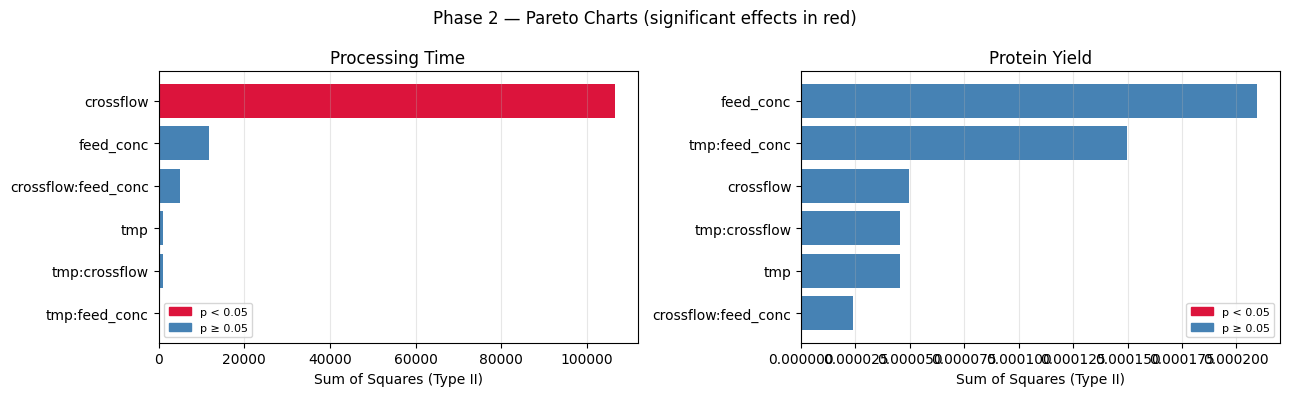

In [5]:
# ── Pareto charts of standardised effects ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

def pareto_plot(ax, fit: AnovaResult, title: str):
    # Exclude residual; sort by |effect|
    tbl    = fit.anova_table.drop(index='Residual', errors='ignore')
    eff    = tbl['sum_sq'].sort_values(ascending=True)
    colors = ['crimson' if fit.anova_table.loc[i,'PR(>F)'] < 0.05
              else 'steelblue'
              for i in eff.index]
    ax.barh(eff.index, eff.values, color=colors)
    ax.set_xlabel('Sum of Squares (Type II)')
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.3)
    # Legend
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='crimson', label='p < 0.05'),
                        Patch(color='steelblue', label='p ≥ 0.05')], fontsize=8)

pareto_plot(axes[0], fit_pt,  'Processing Time')
pareto_plot(axes[1], fit_yld, 'Protein Yield')

fig.suptitle('Phase 2 — Pareto Charts (significant effects in red)', fontsize=12)
plt.tight_layout()
plt.show()

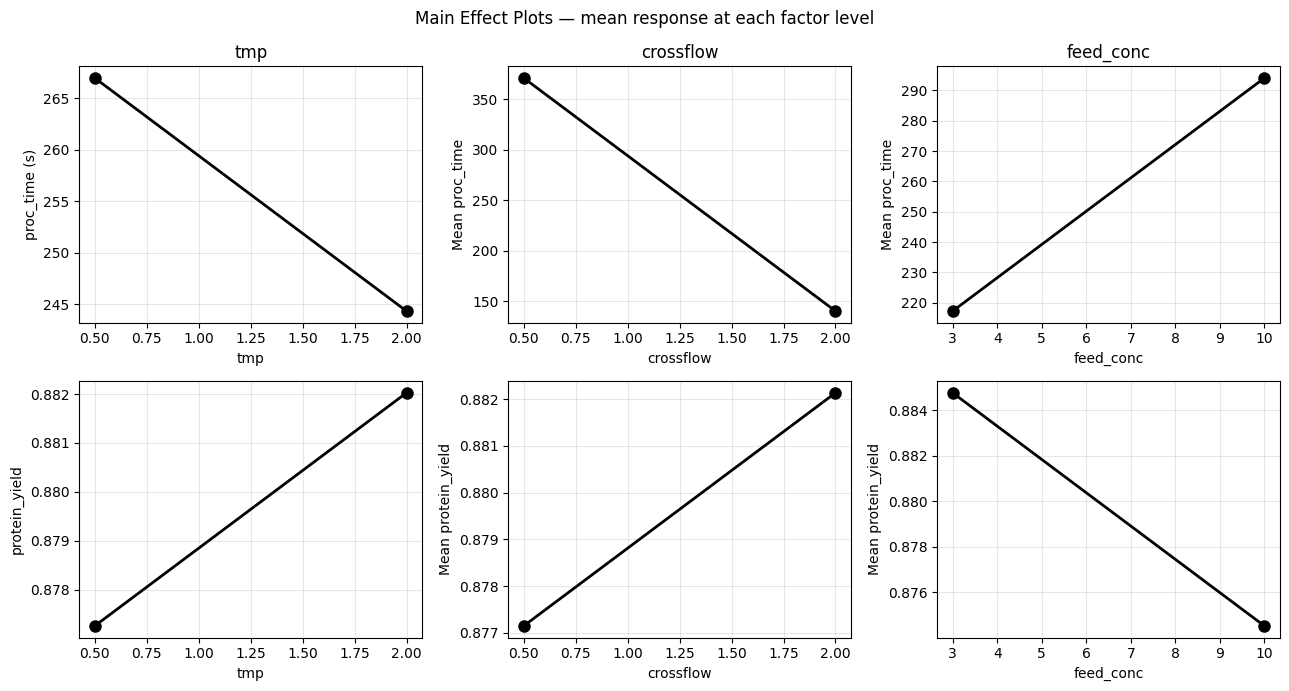

In [6]:
# ── Main-effect + interaction plots ───────────────────────────────────────────
def main_effect_plot(ax, results_df, factor, response, low, high):
    """Plot mean response at factor low vs high level."""
    lo_mean = results_df[results_df[factor] <= (low + (high-low)*0.1)][response].mean()
    hi_mean = results_df[results_df[factor] >= (high - (high-low)*0.1)][response].mean()
    ax.plot([low, high], [lo_mean, hi_mean], 'ko-', ms=8, lw=2)
    ax.set_xlabel(factor)
    ax.set_ylabel(f'Mean {response}')
    ax.grid(alpha=0.3)

fig, axes = plt.subplots(2, 3, figsize=(13, 7))

for col, (factor, fobj) in enumerate(zip(factor_names, FACTORS)):
    main_effect_plot(axes[0, col], results, factor, 'proc_time',    fobj.low, fobj.high)
    axes[0, col].set_title(f'{factor}')
    main_effect_plot(axes[1, col], results, factor, 'protein_yield', fobj.low, fobj.high)

axes[0, 0].set_ylabel('proc_time (s)')
axes[1, 0].set_ylabel('protein_yield')

fig.suptitle('Main Effect Plots — mean response at each factor level', fontsize=12)
plt.tight_layout()
plt.show()

## 2.3  Response Surface — Interaction TMP × Cross-flow

### Interaction geometry

An interaction between factors $i$ and $j$ means the response surface **cannot** be written as a sum of independent functions:

$$\hat{y}(x_i, x_j) \neq f(x_i) + g(x_j)$$

The magnitude of the interaction is $\hat{\beta}_{ij}$: at $x_j = +1$ (high cross-flow), the slope of $\hat{y}$ with respect to $x_i$ is $\hat{\beta}_i + \hat{\beta}_{ij}$, whereas at $x_j = -1$ (low cross-flow) it is $\hat{\beta}_i - \hat{\beta}_{ij}$.  **Non-parallel lines in the interaction plot** are the visual signature of a non-zero $\hat{\beta}_{ij}$.

### Physical mechanism

At **low cross-flow**, a thick concentration-polarisation gel layer builds up on the membrane surface.  Increasing TMP compresses this layer further — the gel, not the applied pressure, limits flux.  At **high cross-flow**, the gel is swept away and the membrane operates in the pressure-controlled regime where TMP has full leverage over flux.

This mechanism produces the fan-like response surface below: the iso-lines of processing time are not horizontal or vertical but curve together in the low-TMP / low-crossflow corner, quantitatively expressed as $\hat{\beta}_{\text{TMP}\times\text{CF}} \neq 0$.

The contour surface is computed directly from the virtual lab (not from the regression approximation) to capture non-linear curvature beyond the first-order model.

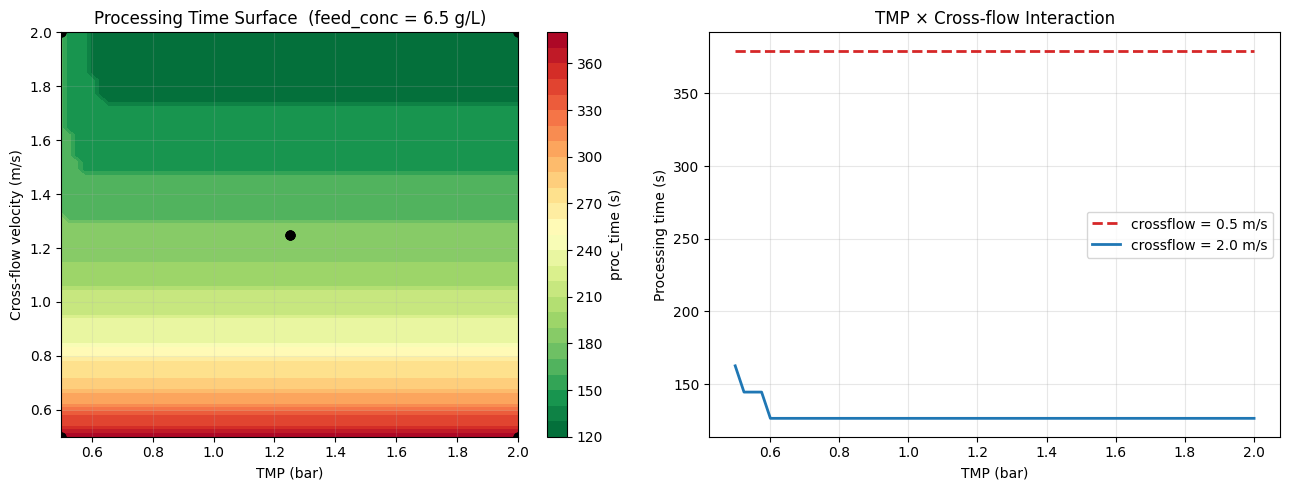

In [7]:
# ── Response-surface contour: TMP vs cross-flow (feed_conc at centre) ─────────
tmp_grid    = np.linspace(0.5, 2.0, 60)
cross_grid  = np.linspace(0.5, 2.0, 60)
TMP_g, CF_g = np.meshgrid(tmp_grid, cross_grid)

# Use the virtual lab directly (no model approximation)
C0_centre = 6.5   # centre of feed_conc

PT_grid = np.zeros_like(TMP_g)
for i in range(TMP_g.shape[0]):
    for j in range(TMP_g.shape[1]):
        r = evaluate_ufdf({'tmp': TMP_g[i,j], 'crossflow': CF_g[i,j], 'feed_conc': C0_centre}, seed=0)
        PT_grid[i, j] = r['proc_time']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Filled contour
cs = axes[0].contourf(TMP_g, CF_g, PT_grid, levels=25, cmap='RdYlGn_r')
plt.colorbar(cs, ax=axes[0], label='proc_time (s)')
axes[0].set_xlabel('TMP (bar)')
axes[0].set_ylabel('Cross-flow velocity (m/s)')
axes[0].set_title(f'Processing Time Surface  (feed_conc = {C0_centre} g/L)')
axes[0].grid(alpha=0.2)

# Mark design points
for _, row in results.iterrows():
    axes[0].scatter(row['tmp'], row['crossflow'], c='black', s=40, zorder=5)

# Interaction plot: proc_time vs TMP at two crossflow levels
for cv_val, ls, col in [(0.5,'--','#d62728'), (2.0,'-','#1f77b4')]:
    pt_vals = [evaluate_ufdf({'tmp':t,'crossflow':cv_val,'feed_conc':C0_centre},seed=0)['proc_time']
               for t in tmp_grid]
    axes[1].plot(tmp_grid, pt_vals, lw=2, ls=ls, color=col,
                 label=f'crossflow = {cv_val} m/s')

axes[1].set_xlabel('TMP (bar)')
axes[1].set_ylabel('Processing time (s)')
axes[1].set_title('TMP × Cross-flow Interaction')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2.4  Proven Acceptable Ranges (PAR) — CMC Narrative

### Mathematical definition

A **Proven Acceptable Range** for factor $X_i$ is the widest interval $[\ell_i,\, u_i]$ such that, when $X_i$ varies within that interval while all other factors are held at their centre values, the predicted response stays within the process specification $[y_{\min}, y_{\max}]$:

$$\text{PAR}_i = \bigl\{X_i \;:\; y_{\min} \leq \hat{y}(X_i,\, X_{-i}^{\text{centre}}) \leq y_{\max}\bigr\}$$

This is a **univariate design space** — it does not capture multi-factor combinations.  ICH Q8/Q10 requires PAR to be derived from a validated regression model with experimental support spanning the full factor range.

### Inversion of the regression model

For the first-order interaction model with all other factors at their coded centres ($x_j = 0$), the cross-terms vanish and the PAR for factor $i$ reduces to a simple inversion:

$$x_i^{\text{PAR}} = \frac{y_{\text{spec}} - \hat{\beta}_0}{\hat{\beta}_i}$$

which back-transforms to natural units via $X_i = X_i^{\text{centre}} + x_i \cdot \tfrac{1}{2}(X_i^{\text{high}} - X_i^{\text{low}})$.

In practice (and in the 1-D slice plots below), the virtual-lab response is scanned directly rather than inverting the polynomial, making the PAR bounds **model-free** and robust to curvature that the linear model does not capture.

In [8]:
# ── PAR derivation ─────────────────────────────────────────────────────────────
nominal_pt = evaluate_ufdf({'tmp':1.25,'crossflow':1.25,'feed_conc':6.5},seed=0)['proc_time']
spec_lo    = nominal_pt * 0.70   # ≤+30% of nominal
spec_hi    = nominal_pt * 1.30

par = proven_acceptable_ranges(fit_pt, response_spec=(spec_lo, spec_hi))

print(f'Nominal processing time: {nominal_pt:.0f} s')
print(f'Specification: [{spec_lo:.0f}, {spec_hi:.0f}] s')
print()
print(par[['factor','par_low','par_high','factor_range_low','factor_range_high']].round(2).to_string(index=False))
print()
print('CMC narrative:')
for _, row in par.iterrows():
    if pd.notna(row['par_low']):
        print(f"  {row['factor']:12s}: PAR [{row['par_low']:.2f} – {row['par_high']:.2f}]  "
              f"(design range [{row['factor_range_low']:.1f} – {row['factor_range_high']:.1f}])")

Nominal processing time: 181 s
Specification: [126, 235] s

   factor  par_low  par_high  factor_range_low  factor_range_high
      tmp     1.28      2.00               0.5                2.0
crossflow     1.25      1.95               0.5                2.0
feed_conc     3.00      6.45               3.0               10.0

CMC narrative:
  tmp         : PAR [1.28 – 2.00]  (design range [0.5 – 2.0])
  crossflow   : PAR [1.25 – 1.95]  (design range [0.5 – 2.0])
  feed_conc   : PAR [3.00 – 6.45]  (design range [3.0 – 10.0])


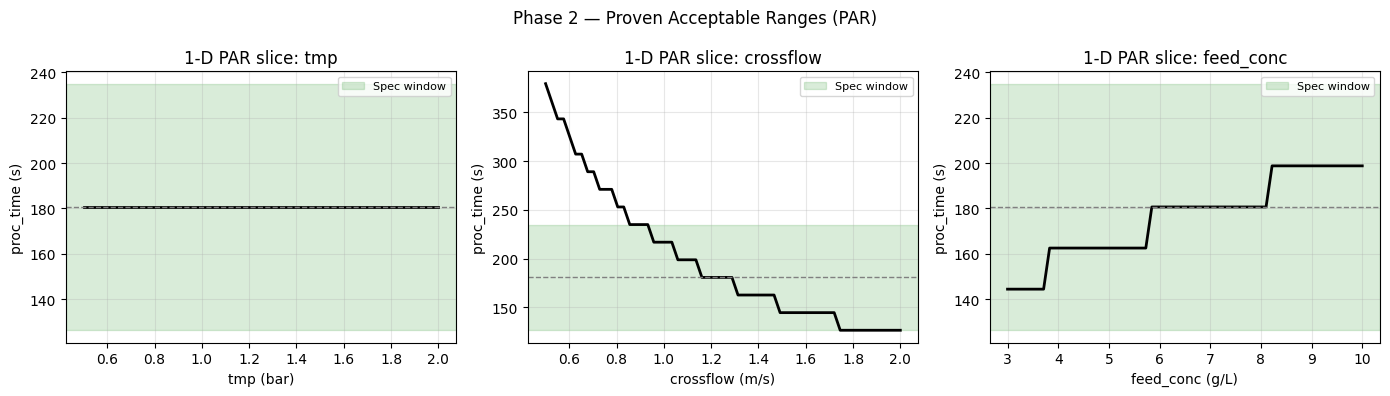

In [9]:
# ── Visual PAR: 1-D slices through the model ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (fname, fobj) in zip(axes, zip(factor_names, FACTORS)):
    x_scan = np.linspace(fobj.low, fobj.high, 60)
    # Centre of other factors
    centre_pt = {f.name: f.center for f in FACTORS}
    y_vals = [evaluate_ufdf({**centre_pt, fname: xv}, seed=0)['proc_time']
              for xv in x_scan]
    ax.plot(x_scan, y_vals, 'k-', lw=2)
    ax.axhspan(spec_lo, spec_hi, alpha=0.15, color='green', label='Spec window')
    ax.axhline(nominal_pt, ls='--', color='gray', lw=1)
    ax.set_xlabel(f'{fname} ({"bar" if fname=="tmp" else "m/s" if fname=="crossflow" else "g/L"})')
    ax.set_ylabel('proc_time (s)')
    ax.set_title(f'1-D PAR slice: {fname}')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('Phase 2 — Proven Acceptable Ranges (PAR)', fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
# ── Save DoE results for use in later notebooks ───────────────────────────────
save_path = PROCESSED_DATA_DIR / 'doe_ufdf_factorial.csv'
results.to_csv(save_path)
print(f'Saved factorial results → {save_path}')

Saved factorial results → /home/ali/projects/DOE/data/processed/doe_ufdf_factorial.csv


---
## Phase 2 Summary

**Key findings from the full-factorial DoE:**

1. **Cross-flow velocity** is the dominant driver of processing time — higher cross-flow improves mass transfer, reduces gel-layer thickness, and dramatically increases flux.
2. **TMP × crossflow interaction** is significant: the benefit of increased TMP is only realised when cross-flow is also high (gel layer limits the pressure-driven flux at low cross-flow).
3. **Feed concentration** has a moderate effect — higher feed concentration increases polarisation and slows processing.
4. **PAR** for processing time within ±30% of nominal is widest for TMP (robust over the full design range) and narrowest for cross-flow (must be controlled above a minimum threshold).

**CMC statement:** *"The UF step is robust to variation in TMP over [X–Y bar] when cross-flow velocity is maintained above Z m/s.  Feed concentration should be controlled within [A–B g/L] to ensure consistent processing time."*

Next: **Phase 3** — Latin Hypercube Sampling to map a higher-dimensional design space.